# Coarse-to-Fine FOGAS on the 100 x 100 Grid

**Objective.** This notebook is the final gridworld stress test. It asks whether a 20 x 20 RBF representation and temporal abstraction can control a 100 x 100 environment without treating all 10,000 fine states as independent tabular optimization variables.

**Protocol.** A direct policy learned on the 20 x 20 problem is compared with a macro policy learned from 100 x 100 trajectories. Fine data are generated with an exploratory down/right heuristic and a mixture of nominal and border-state resets; every five repeated fine actions form one coarse transition. The same coarse feature centers are used throughout.

**Evidence.** The learned 20 x 20 macro policies are expanded to the fine state space and executed for five environment steps per decision. The final comparison reports fine-grid trajectories, returns, and goal success. Execute the notebook in order; inputs and generated datasets are located under `data/datasets/large_100grid/`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from IPython.display import Image, display

# This starts from the current working directory
# and goes up until it finds src/rl_methods at the repository root
def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets" / "large_100grid"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
print(f"Project root found at: {PROJECT_ROOT}")

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Now define the dataset path
DATASET_PATH = DATASETS_DIR / "20data.csv"
MACRO_DATASET_PATH_100_20 = DATASET_PATH.parent / "coarse_100_20.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from rl_methods.fogas import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from rl_methods.data_collection import (
    DiscreteDataBuffer,
    DatasetAnalyzer,
)

from rl_methods.mdp import DiscreteMDP, Planner

from rl_methods.fqi.fqi_solver import FQISolver
from rl_methods.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_100grid/20data.csv
Using device: cuda


# Problem

### Scaling

In [2]:
def scale_grid(small_grid, factor=5):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S and G at the scaled positions of the original ones.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    # Find original S and G
    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated S/G blocks
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'

    # Put one unique S/G at scaled coordinates
    s_big = tuple((s_pos * factor).tolist())
    g_big = tuple((g_pos * factor + (factor - 1)).tolist())  # choose bottom-right of block for G

    large_grid[s_big] = 'S'
    large_grid[g_big] = 'G'

    return large_grid

def scale_grid_goal_block(small_grid, factor=2):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S, but expand G to the full factor x factor block.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated start block only
    large_grid[large_grid == 'S'] = '.'

    # Reinsert one unique start at the top-left of the scaled start block
    s_big = tuple((s_pos * factor).tolist())
    large_grid[s_big] = 'S'

    # Expand the goal to the full fine block
    g_r, g_c = (g_pos * factor).tolist()
    large_grid[g_r:g_r + factor, g_c:g_c + factor] = 'G'

    return large_grid


### Path methods

In [3]:
def compute_optimal_path(mdp, planner, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following planner.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the planner's pi_star vector at the current state
        best_a = torch.argmax(planner.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


def sample_policy_path(mdp, mdp_data, size, pi, max_steps=1000, rng=None):
    """
    Sample one trajectory from a policy pi.

    Args:
        mdp: DiscreteMDP object
        mdp_data: dict with keys 'start', 'goal', 'pits'
        size: grid side length
        pi: tensor of shape (N, A), for example planner.pi_star or solver.pi
        max_steps: safety limit
        rng: numpy random generator (optional)

    Returns:
        path: list of (row, col)
        states: list of visited state indices
        actions: list of sampled action indices
    """
    if rng is None:
        rng = np.random.default_rng()

    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = set(mdp_data["pits"])

    path = []
    states = []
    actions = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))
        states.append(current_state)

        if current_state == goal_state or current_state in pits:
            break

        action_probs = pi[current_state].detach().cpu().numpy()
        action_probs = action_probs / action_probs.sum()

        a = rng.choice(mdp.A, p=action_probs)
        actions.append(int(a))

        transition_probs = mdp.P[current_state * mdp.A + a].detach().cpu().numpy()
        next_state = rng.choice(mdp.N, p=transition_probs)

        if next_state == current_state:
            break

        current_state = int(next_state)

    return path, states, actions


def sample_multiple_policy_paths(mdp, mdp_data, size, pi, n_paths=20, max_steps=1000, seed=None):
    """
    Sample multiple trajectories from a policy.

    Returns:
        paths: list of paths, each path is a list of (row, col)
        states_list: list of state-index trajectories
        actions_list: list of action-index trajectories
    """
    rng = np.random.default_rng(seed)

    paths = []
    states_list = []
    actions_list = []

    for _ in range(n_paths):
        path, states, actions = sample_policy_path(
            mdp=mdp,
            mdp_data=mdp_data,
            size=size,
            pi=pi,
            max_steps=max_steps,
            rng=rng
        )
        paths.append(path)
        states_list.append(states)
        actions_list.append(actions)

    return paths, states_list, actions_list


def unique_paths(paths):
    """
    Remove duplicate paths while preserving order.

    Args:
        paths: list of paths, where each path is a list of (row, col)

    Returns:
        unique: list of unique paths
    """
    seen = set()
    unique = []

    for path in paths:
        key = tuple(path)
        if key not in seen:
            seen.add(key)
            unique.append(path)

    return unique


def sample_unique_policy_paths(mdp, mdp_data, size, pi, n_samples=200, max_unique=10, max_steps=1000, seed=None):
    """
    Sample many trajectories and keep up to max_unique distinct ones.
    """
    paths, _, _ = sample_multiple_policy_paths(
        mdp=mdp,
        mdp_data=mdp_data,
        size=size,
        pi=pi,
        n_paths=n_samples,
        max_steps=max_steps,
        seed=seed
    )

    uniq = unique_paths(paths)
    return uniq[:max_unique]

### Plotting methods

In [4]:
def _grid_major_step(size):
    if size <= 20:
        return 5
    if size <= 80:
        return 10
    return 20


def plot_fogas_grid(grid_data):
    """
    Visualizes grids of any size for RL analysis.
    Same plotting style as large_20 / large_40.
    """
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    ax.set_title(f"FOGAS Environment - {size}x{size} Grid", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]
    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()


def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix="", alpha=0.75):
    """
    Overlay trajectories on the grid using the large_20 / large_40 style.
    """
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    line_styles = ["-", "--", ":", "-."]
    path_colors = ["magenta", "cyan", "yellow", "orange", "lime", "purple"]

    for i, path in enumerate(paths):
        if not path:
            continue

        label = labels[i] if labels and i < len(labels) else f"Path {i + 1}"
        rows, cols = zip(*path)
        color = path_colors[i % len(path_colors)]

        ax.plot(
            cols,
            rows,
            label=label,
            color=color,
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2,
            marker="o",
            markersize=3,
            alpha=alpha,
        )

        ax.scatter(cols[0], rows[0], marker="s", s=60, color=color, zorder=5)
        ax.scatter(cols[-1], rows[-1], marker="*", s=120, color=color, zorder=5)

    ax.set_title(f"FOGAS Path Comparison: {size}x{size} {title_suffix}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()

## GRID 

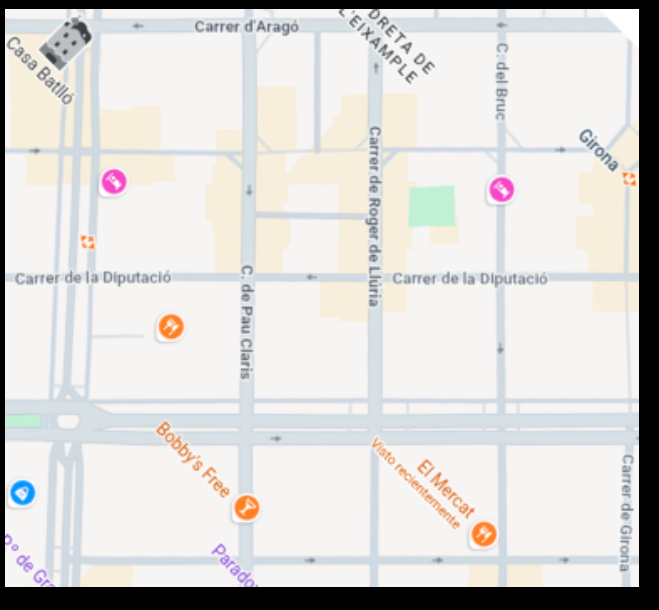

In [5]:
display(Image(filename=str(ASSETS_DIR / "grid_barcelona.png")))

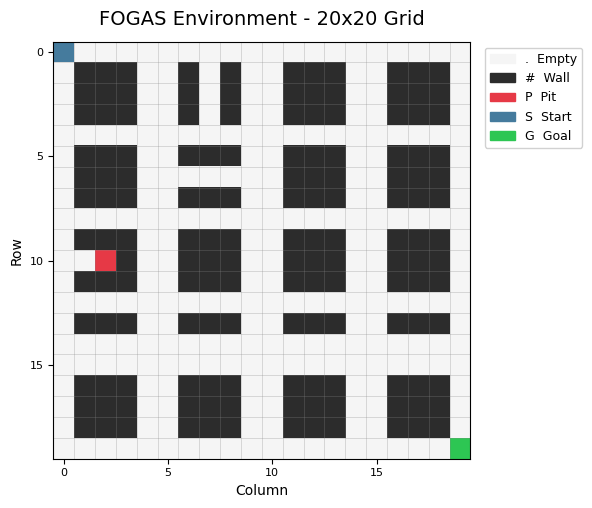

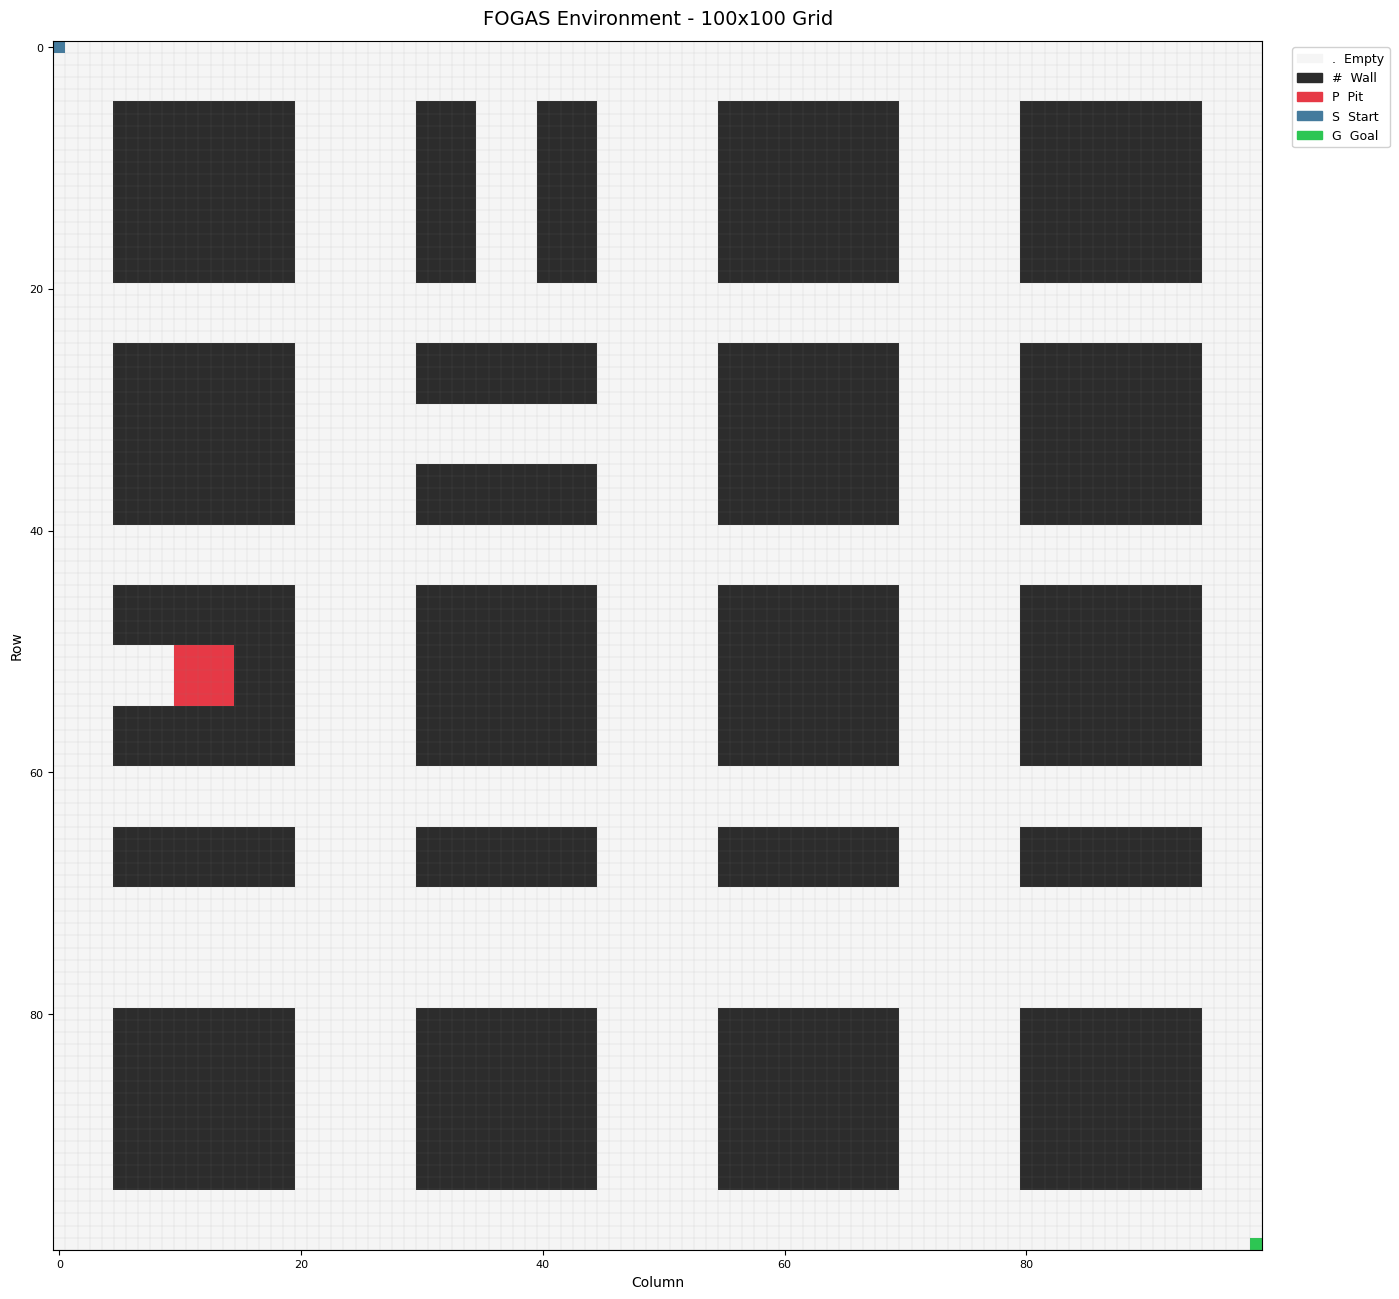

In [6]:
grid_layout = [
    "S...................",
    ".###..#.#..###..###.",
    ".###..#.#..###..###.",
    ".###..#.#..###..###.",
    "....................",
    ".###..###..###..###.",
    ".###.......###..###.",
    ".###..###..###..###.",
    "....................",
    ".###..###..###..###.",
    "..P#..###..###..###.",
    ".###..###..###..###.",
    "....................",
    ".###..###..###..###.",
    "....................",
    "....................",
    ".###..###..###..###.",
    ".###..###..###..###.",
    ".###..###..###..###.",
    "...................G",
]

grid_20 = np.array([list(row) for row in grid_layout])

plot_fogas_grid(grid_20)

grid_40 = scale_grid(grid_20, factor=5)
plot_fogas_grid(grid_40)

### MDP and Features Helpers

In [7]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4

    walls = set(np.where(grid_data.flatten() == "#")[0])
    pits = set(np.where(grid_data.flatten() == "P")[0])
    goal = int(np.where(grid_data.flatten() == "G")[0][0])
    start_node = int(np.where(grid_data.flatten() == "S")[0][0])

    # Regular Grid Center Generation
    target_num_centers = int(N * 0.5)
    centers_per_side = int(np.sqrt(target_num_centers))

    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(
        np.column_stack([c_x.ravel(), c_y.ravel()]),
        dtype=torch.float64,
    )

    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal:
            return 10.0
        if x_int in pits:
            return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)

    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue

            r, c = divmod(x, size)

            if a == 0:
                r_n, c_n = max(0, r - 1), c
            elif a == 1:
                r_n, c_n = min(size - 1, r + 1), c
            elif a == 2:
                r_n, c_n = r, max(0, c - 1)
            elif a == 3:
                r_n, c_n = r, min(size - 1, c + 1)

            next_s = r_n * size + c_n

            if next_s in walls:
                next_s = x

            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers,
        "walls": walls,
        "pits": pits,
        "goal": goal,
        "start": start_node,
        "reward_fn": reward_fn,
        "P": P,
        "N": N,
        "A": A,
        "gamma": gamma,
    }


def build_clean_mdp_from_grid_data(mdp_data):
    terminal_states = list(mdp_data["pits"]) + [mdp_data["goal"]]

    mdp = DiscreteMDP(
        states=torch.arange(mdp_data["N"]),
        actions=torch.arange(mdp_data["A"]),
        gamma=mdp_data["gamma"],
        x0=mdp_data["start"],
        reward_fn=mdp_data["reward_fn"],
        P=mdp_data["P"],
        terminal_states=terminal_states,
    )

    planner = Planner(mdp)

    return mdp, planner


def get_phi_func(centers, sigma, size, pits, goal, A):
    """
    Returns state-action feature function for FOGAS clean.

    phi(x, a) = one_hot(a) kron phi_state(x)
    """
    def phi_state(x):
        r, c = divmod(int(x), size)
        coords = torch.tensor(
            [r / (size - 1), c / (size - 1)],
            dtype=torch.float64,
        )

        dist_sq = torch.sum((coords - centers) ** 2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma ** 2))

        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)

        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])

    def phi(x, a):
        state_feat = phi_state(x)
        d_state = state_feat.shape[0]

        out = torch.zeros(A * d_state, dtype=torch.float64)
        start = int(a) * d_state
        out[start:start + d_state] = state_feat

        return out

    return phi


def calculate_local_sigma(centers, k=2):
    """
    Computes sigma based on k-nearest neighbors for spatial precision.
    """
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])


def plot_grid_with_centers(grid_data, centers):
    """
    Visualizes the grid with RBF feature centers overlaid.
    Same style as large_20 / large_40.
    """
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    centers_scaled = centers.detach().cpu().numpy() * (size - 1)
    marker_size = max(15, min(80, 250 / np.sqrt(size)))

    ax.scatter(
        centers_scaled[:, 1],
        centers_scaled[:, 0],
        c="blue",
        marker="x",
        s=marker_size,
        linewidths=1.2,
        label="RBF Feature Centers",
        alpha=0.65,
        zorder=5,
    )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]

    grid_legend = ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        framealpha=0.9,
        title="Grid",
    )
    ax.add_artist(grid_legend)

    ax.legend(
        bbox_to_anchor=(1.02, 0.58),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(f"FOGAS Feature Allocation - {size}x{size}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    plt.tight_layout()
    plt.show()

# Strategy 1 - Solve coarse grid

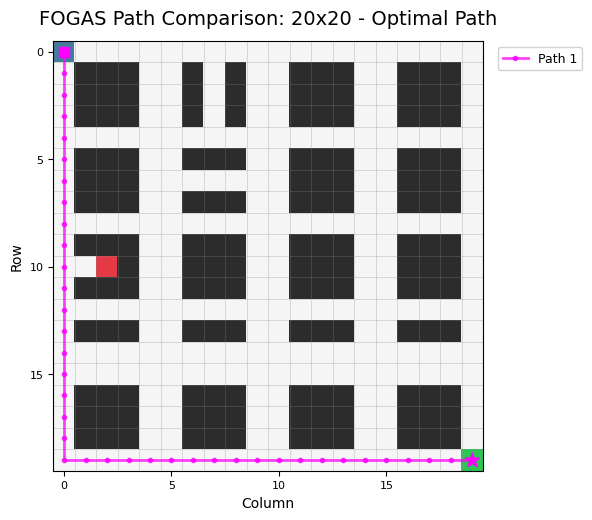

In [8]:
size = 20

# --- STEP 2: Generate MDP Components with Regular Grid ---
mdp_data = generate_mdp_regular_grid(grid_20)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Function ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi = get_phi_func(
    centers=centers,
    sigma=rbf_sigma,
    size=size,
    pits=mdp_data["pits"],
    goal=mdp_data["goal"],
    A=mdp_data["A"],
)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the Clean MDP and Planner Objects ---
mdp, planner = build_clean_mdp_from_grid_data(mdp_data)

optimal_path = compute_optimal_path(
    mdp=mdp,
    planner=planner,
    mdp_data=mdp_data,
    size=size,
)

# Plot the trajectory
plot_agent_paths_with_labels(
    grid_20,
    [optimal_path],
    title_suffix="- Optimal Path",
)

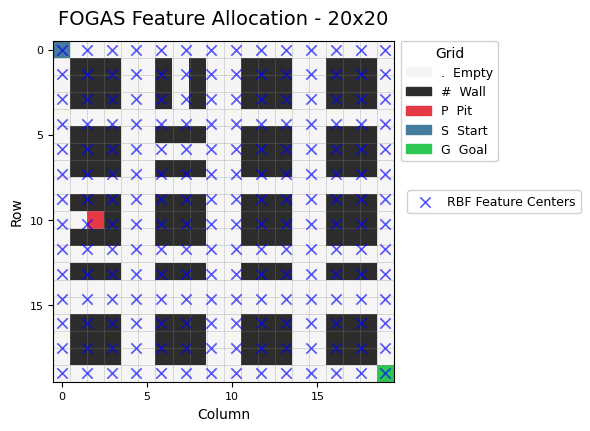

In [9]:
plot_grid_with_centers(grid_data=grid_20, centers=centers)

### Dataset creation

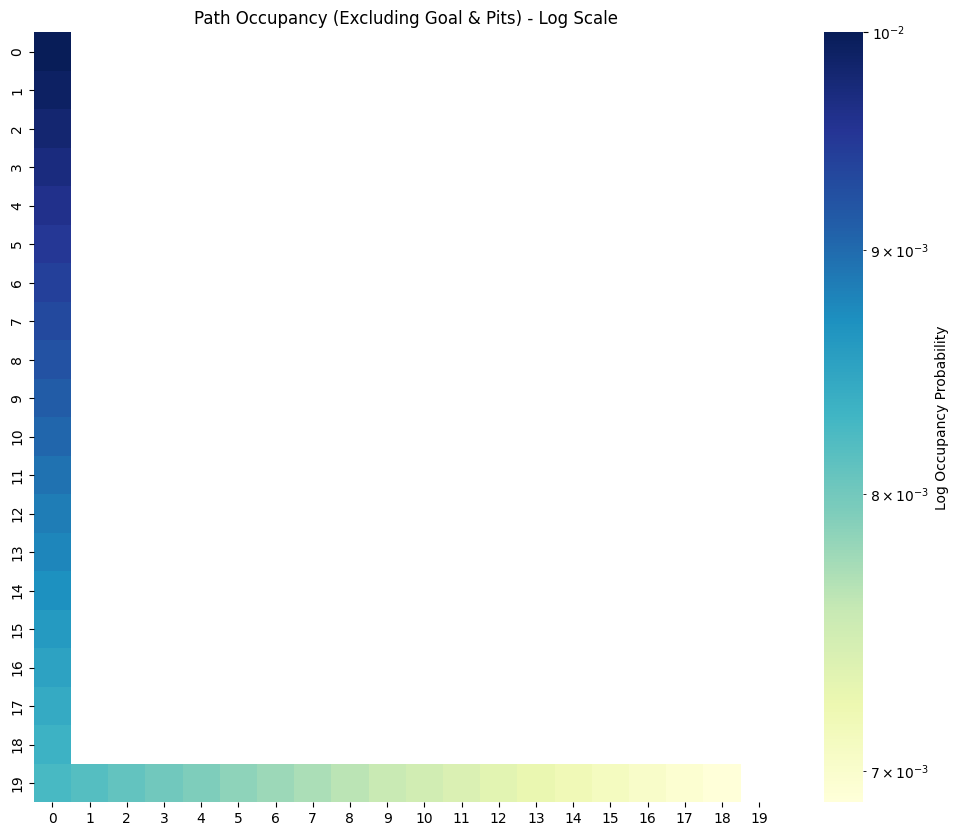

Collected 20000 transitions over 331 episodes.
Policy distribution:
policy_id
0    0.6997
1    0.3003
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    0.8802
x0           0.1198
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_100grid/20data.csv


In [10]:
# 1. Get occupancy probabilities
probs = planner.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data["pits"]) + [mdp_data["goal"]]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = size
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid,
    cmap="YlGnBu",
    norm=LogNorm(
        vmin=probs[probs > 0].min() if any(probs > 0) else 1e-6,
        vmax=probs.max(),
    ),
    cbar_kws={"label": "Log Occupancy Probability"},
)

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()

reset_options = {
    "x0": 0.1,
    "occupancy": 0.9,
}

# Initialize the collector with these options
collector = DiscreteDataBuffer(
    mdp=mdp,
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    occupancy=planner.state_mu_star,
    max_steps=100,
    seed=seed,
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (planner.pi_star, 0.3)

df = collector.collect(
    policies=[epsilon_policy, "random"],
    proportions=[0.8, 0.2],
    n_steps=20000,
    episode_based=True,
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_terminal_steps=20,
)

Total states: 400
Walls: 148
Visited: 208
Non-visited non-walls: 44


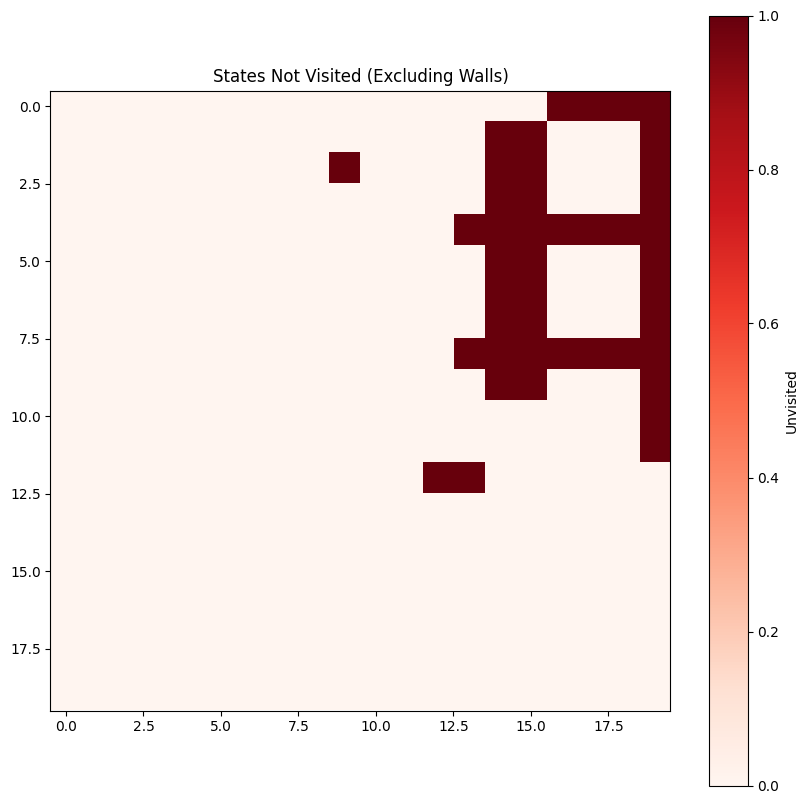

In [11]:
# 1. Get all visited states from your collected dataset
visited_states = set(df["state"].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data["walls"])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = grid_20.shape[0]
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap="Reds")
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()

### Solving it

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=20000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
--------------------------------------------
Max |error|                        0.091967
Mean |error|                       0.004657
RMSE                               0.009924
R2 (explained variance)            0.999803


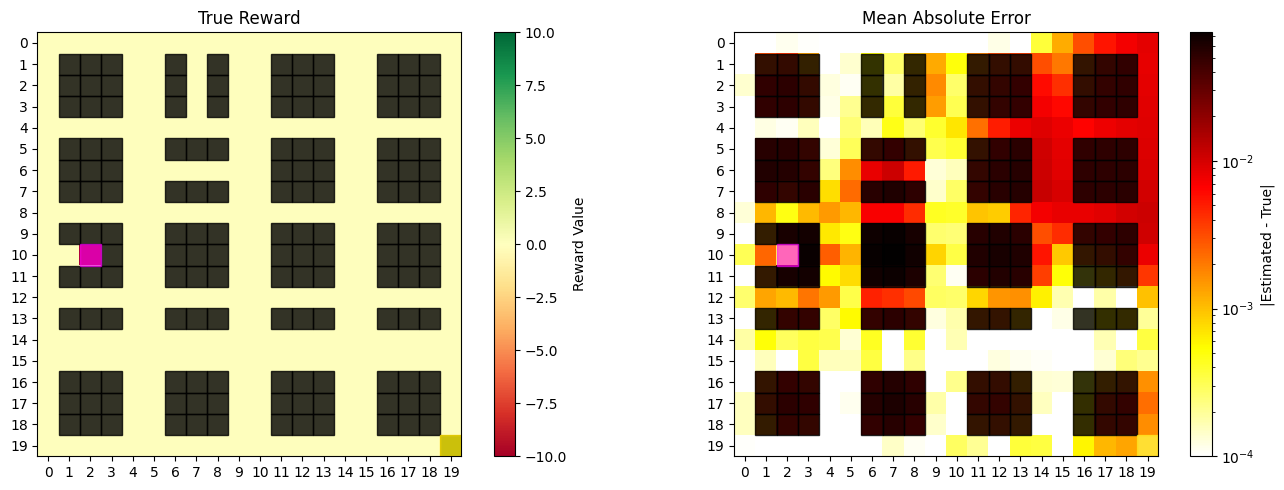

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [03:40<00:00, 113.21it/s]



  PATH VISUALIZATION - Solver Policy (solver)

Initial State: 0
Goal State: 399
Terminal States: [202, 399]
Discount Factor (gamma): 0.99

----------------------------------------------------------------------

  Step   0 | State: tensor(0, device='cuda:0') | Action: tensor(2, device='cuda:0') | Reward:  -0.010 | -> 0 SELF-LOOP
  Step   1 | State: tensor(0, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.010 | -> 1
  Step   2 | State: tensor(1, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.010 | -> 2
  Step   3 | State: tensor(2, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.010 | -> 3
  Step   4 | State: tensor(3, device='cuda:0') | Action: tensor(1, device='cuda:0') | Reward:  -0.010 | -> 3 SELF-LOOP
  Step   5 | State: tensor(3, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.010 | -> 4
  Step   6 | State: tensor(4, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.010 | -> 5
  Ste

In [12]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="greedy_average_return",
    metric_kwargs={
        "num_trajectories": 10,
        "max_steps": 100,
        "seed": seed,
        "goal_state": mdp_data["goal"],
        "terminal_states": list(mdp_data["pits"]) + [mdp_data["goal"]],
    },
    seed=seed,
)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"],
    pits=mdp_data["pits"],
    goal=mdp_data["goal"],
)

# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001, eta=0.00002, rho=0.5, tqdm_print=True, T=25000)

evaluator_e.print_optimal_path(
    goal_state=mdp_data["goal"],
    terminal_states=list(mdp_data["pits"]) + [mdp_data["goal"]],
)

In [13]:
NUM_EVAL_TRAJ = 100
MAX_EVAL_STEPS = 100

terminal_states_e = list(mdp_data["pits"]) + [mdp_data["goal"]]

avg_reward_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    goal_state=mdp_data["goal"],
    terminal_states=terminal_states_e,
    compare_with_optimal=True,
)

greedy_reward_e = evaluator_e.average_return(
    policy_mode="greedy",
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    goal_state=mdp_data["goal"],
    terminal_states=terminal_states_e,
    compare_with_optimal=True,
)

success_rate_e = evaluator_e.success_rate(
    policy_mode="solver",
    goal_state=mdp_data["goal"],
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    terminal_states=terminal_states_e,
    compare_with_optimal=True,
)

print(f"Avg reward:             {avg_reward_e['policy']:.6f}")
print(f"Greedy reward:          {greedy_reward_e['policy']:.6f}")
print(f"Optimal avg reward:     {avg_reward_e['optimal']:.6f}")
print(f"Success rate:           {success_rate_e['policy']:.3f}")
print(f"Optimal success rate:   {success_rate_e['optimal']:.3f}")

Avg reward:             -0.434756
Greedy reward:          -0.317445
Optimal avg reward:     -0.317445
Success rate:           0.680
Optimal success rate:   1.000


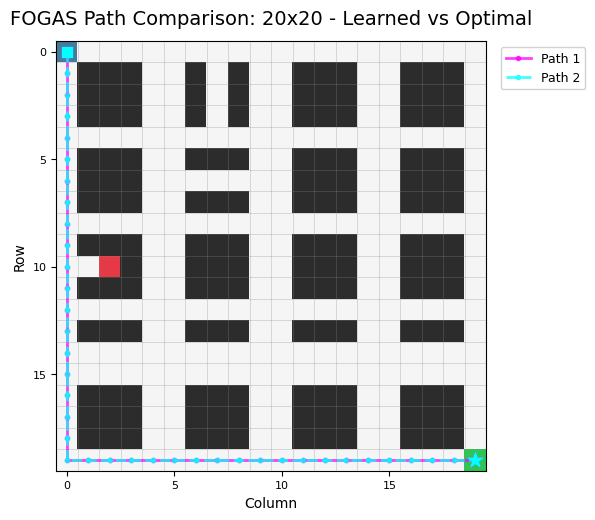

In [15]:
traj = evaluator_e.simulate_trajectory(
    policy_mode="greedy",
    goal_state=mdp_data["goal"],
    terminal_states=list(mdp_data["pits"]) + [mdp_data["goal"]],
    max_steps=38,
)

size = grid_20.shape[0]

# Extract 'state' from all steps + append the final 'next_state' to include the goal
path_coords = [divmod(step["state"], size) for step in traj]
if traj:
    path_coords.append(divmod(traj[-1]["next_state"], size))  # add the goal

traj_opt = evaluator_e.simulate_trajectory(
    pi=planner.pi_star,
    goal_state=mdp_data["goal"],
    terminal_states=list(mdp_data["pits"]) + [mdp_data["goal"]],
    max_steps=38,
)

path_opt = [divmod(step["state"], size) for step in traj_opt]
if traj_opt:
    path_opt.append(divmod(traj_opt[-1]["next_state"], size))  # add the goal

plot_agent_paths_with_labels(
    grid_20,
    [path_coords, path_opt],
    title_suffix="- Learned vs Optimal",
)

# Strategy 2- data collection in fine grid

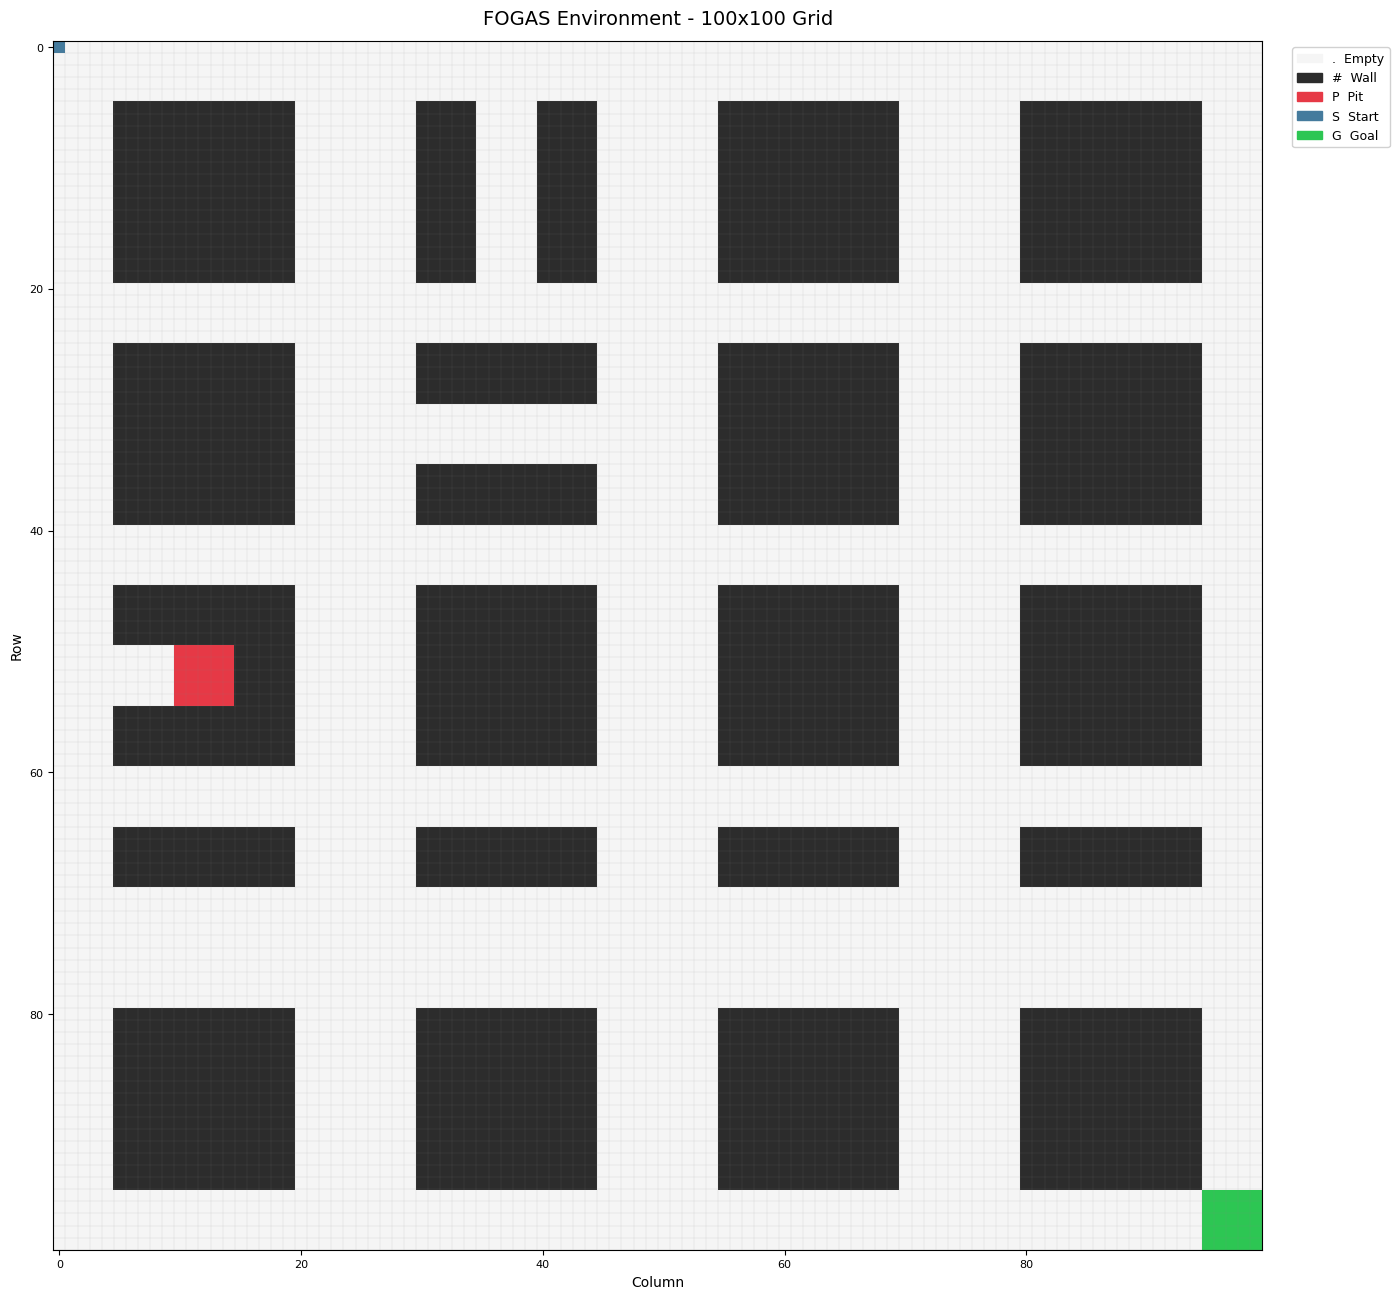

In [17]:
grid_100 = scale_grid_goal_block(grid_20, factor=5)
plot_fogas_grid(grid_100)


# 1. Define base grid and scale it
grid_20  = np.array([list(row) for row in grid_layout])
grid_100 = scale_grid(grid_20, factor=5)
size_20, size_100 = grid_20.shape[0], grid_100.shape[0]

# 2. Generate MDP components 
mdp_data_20  = generate_mdp_regular_grid(grid_20)
mdp_data_100 = generate_mdp_regular_grid(grid_100, gamma=(mdp_data_20["gamma"] ** 5))

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_20["centers"]
fixed_sigma   = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 20x20 feature map to avoid stale closures
phi_20_fixed = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_20,
    mdp_data_20["pits"],
    mdp_data_20["goal"],
    mdp_data_20["A"],
)

# 5. Define the 100x100 feature map using the exact same centers
phi_100_fixed = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_100,
    mdp_data_100["pits"],
    mdp_data_100["goal"],
    mdp_data_100["A"],
)

# --- STEP 7: Create the FOGAS Solver Object for 100x100 ---
mdp_100 = DiscreteMDP(
    states=torch.arange(mdp_data_100["N"]),
    actions=torch.arange(mdp_data_100["A"]),
    gamma=mdp_data_100["gamma"],
    x0=mdp_data_100["start"],
    reward_fn=mdp_data_100["reward_fn"],
    P=mdp_data_100["P"],
    terminal_states=list(mdp_data_100["pits"]) + [mdp_data_100["goal"]],
)

### Coarse conversion


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Build the 20×20 macro MDP
# ─────────────────────────────────────────────────────────────────────────────
MACRO_FACTOR = 5
gamma_fine   = mdp_data_100["gamma"] 
gamma_macro  = gamma_fine ** (1 / MACRO_FACTOR)  

def make_macro_reward_fn(pits, goal, gamma_fine, factor,
                         step_penalty=-0.01, goal_reward=10.0, pit_reward=-10.0):
    # Non-terminal macro step: Σ_{k=0}^{factor-1} γ^k · step_penalty
    macro_step_penalty = step_penalty * sum(gamma_fine**k for k in range(factor))
    def reward_fn(x, a):
        if int(x) == goal:   return goal_reward
        if int(x) in pits:   return pit_reward
        return macro_step_penalty
    return reward_fn

macro_reward_fn = make_macro_reward_fn(
    pits       = mdp_data_20["pits"],
    goal       = mdp_data_20["goal"],
    gamma_fine = gamma_fine,
    factor     = MACRO_FACTOR,
)

def phi_macro(x, a):
    return phi_20_fixed(x, a)      # same 20×20 RBF centers — no retraining

terminal_states_macro = list(mdp_data_20["pits"]) + [mdp_data_20["goal"]]

mdp_macro = DiscreteMDP(
    states    = torch.arange(size_20 * size_20, dtype=torch.int64),
    actions   = torch.arange(4, dtype=torch.int64),
    reward_fn = macro_reward_fn,
    gamma     = gamma_macro,
    x0        = mdp_data_20["start"],
    P         = mdp_data_20["P"],
    terminal_states = terminal_states_macro,
)

planner_macro = Planner(mdp_macro)

#### Dataset collection


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Heuristic policy: 50% down (a=1), 50% right (a=3)
#    Falls back to the other direction if at the grid boundary.
# ─────────────────────────────────────────────────────────────────────────────
class DownRightPolicy:
    """
    Greedy heuristic: go down or right with equal probability.
    At the bottom edge (last row) → always go right.
    At the right edge (last col) → always go down.
    At bottom-right corner       → stay (should be the goal).
    """
    def __init__(self, grid_size):
        self.size = grid_size

    def sample(self, state):
        state = int(state)
        row, col = divmod(state, self.size)
        at_bottom = (row == self.size - 1)
        at_right  = (col == self.size - 1)

        if at_bottom and at_right:
            return random.choice([1, 3])   # corner: both actions stay
        elif at_bottom:
            return 3   # can only go right
        elif at_right:
            return 1   # can only go down
        else:
            return random.choice([1, 3])   # 50% down, 50% right

pi_heuristic = DownRightPolicy(grid_size=size_100)

# ─────────────────────────────────────────────────────────────────────────────
# 3. Custom initial states: uniform over first column ∪ last row
#    (excluding walls, pits, and the goal)
# ─────────────────────────────────────────────────────────────────────────────
walls_100 = mdp_data_100["walls"]
pits_100  = mdp_data_100["pits"]
goal_100  = mdp_data_100["goal"]
forbidden = walls_100 | pits_100 | {goal_100}

first_col_states = [row * size_100 + 0 for row in range(size_100)]
last_row_states  = [(size_100 - 1) * size_100 + col for col in range(size_100)]

# Union, deduplicate and filter forbidden
border_states = list({
    s for s in first_col_states + last_row_states
    if s not in forbidden
})

print(f"Valid border start states: {len(border_states)} "
      f"(first col + last row, excluding walls/pits/goal)")

# ─────────────────────────────────────────────────────────────────────────────
# Collector for macro dataset: random restarts for better coarse coverage
# ─────────────────────────────────────────────────────────────────────────────
collector_macro = DiscreteDataBuffer(
    mdp=mdp_100,
    reset_probs={"x0": 0.3, "custom": 0.7},   # uniform over custom border states
    initial_states=border_states,
    max_steps=500,                            # longer: 5 fine steps × many macro steps
    seed=seed,
)

df_macro_100_20 = collector_macro.collect_macro_dataset_n_repeated_actions(
    policy=(pi_heuristic, 0.3),   # 70% down/right + 30% random
    n_macro_steps=25000,
    gamma=mdp_data_100["gamma"],
    fine_size=size_100,           # 100
    coarse_size=size_20,          # 20
    factor=5,
    save_path=str(MACRO_DATASET_PATH_100_20),
    verbose=True,
)

Valid border start states: 198 (first col + last row, excluding walls/pits/goal)
Collected 25000 macro transitions (5 fine steps each).
Saved FOGAS macro dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_100grid/coarse_100_20.csv


### Run coarse MDP


[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=25000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
--------------------------------------------
Max |error|                       26.666541
Mean |error|                       0.293534
RMSE                               1.855603
R2 (explained variance)           -5.883182

--------------------------------------------------
State        Action         r_true      r_hat      error
--------------------------------------------------------
0            Up            -0.0453    -0.0453     0.0000
0            Down          -0.0453    -0.0453     0.0000
0            Left          -0.0453    -0.0453     0.0000
0            Right         -0.0453    -0.0424     0.0030
1            Up            -0.0453    -0.0453    -0.0000
1            Down          -0.0453    -0.0454    -0.0000
1            Left          -0.0453    -0.0453    -0.0000
1            Right         -0.0453    -0.0478    -0.0025
2

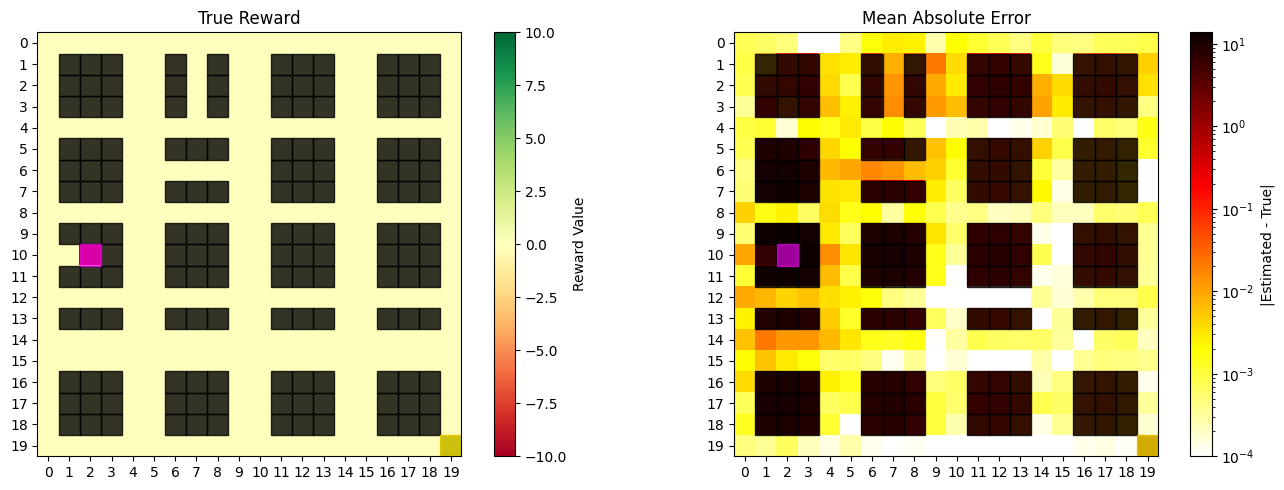

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [04:34<00:00, 91.10it/s]


  PATH VISUALIZATION - Solver Policy (solver)

Initial State: 0
Goal State: 399
Terminal States: [202, 399]
Discount Factor (gamma): 0.99

----------------------------------------------------------------------

  Step   0 | State: tensor(0, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.045 | -> 1
  Step   1 | State: tensor(1, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.045 | -> 2
  Step   2 | State: tensor(2, device='cuda:0') | Action: tensor(2, device='cuda:0') | Reward:  -0.045 | -> 1
  Step   3 | State: tensor(1, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.045 | -> 2
  Step   4 | State: tensor(2, device='cuda:0') | Action: tensor(1, device='cuda:0') | Reward:  -0.045 | -> 2 SELF-LOOP
  Step   5 | State: tensor(2, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.045 | -> 3
  Step   6 | State: tensor(3, device='cuda:0') | Action: tensor(3, device='cuda:0') | Reward:  -0.045 | -> 4
  Step   7 | St

In [23]:
solver_macro = FOGASSolver(
    mdp      = mdp_macro,
    phi      = phi_macro,
    csv_path = str(MACRO_DATASET_PATH_100_20),
    device   = device,
    beta     = 1e-7,
    seed     = seed,
)

evaluator_macro = FOGASEvaluator(
    solver  = solver_macro,
    mdp     = mdp_macro,
    planner = planner_macro,
)

optimizer_macro = FOGASHyperOptimizer(
    solver    = solver_macro,
    evaluator = evaluator_macro,
    metric    = "greedy_average_return",
    metric_kwargs = {
        "num_trajectories": 10,
        "max_steps": 100,
        "seed": seed,
        "goal_state": mdp_data_20["goal"],
        "terminal_states": list(mdp_data_20["pits"]) + [mdp_data_20["goal"]],
    },
    seed = seed,
)

evaluator_macro.analyze_reward_approximation(
    walls      = mdp_data_20["walls"],
    pits       = mdp_data_20["pits"],
    goal       = mdp_data_20["goal"],
    print_each = True,
)

solver_macro.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=25000
)

evaluator_macro.print_optimal_path(
    goal_state=mdp_data_20["goal"],
    terminal_states=list(mdp_data_20["pits"]) + [mdp_data_20["goal"]],
    show_value_info=False,
)

In [25]:
NUM_EVAL_TRAJ = 100
MAX_EVAL_STEPS = 400

terminal_states_macro = list(mdp_data_20["pits"]) + [mdp_data_20["goal"]]

avg_reward_macro = evaluator_macro.average_return(
    policy_mode="solver",
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    goal_state=mdp_data_20["goal"],
    terminal_states=terminal_states_macro,
    compare_with_optimal=True,
)

success_rate_macro = evaluator_macro.success_rate(
    policy_mode="solver",
    goal_state=mdp_data_20["goal"],
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    terminal_states=terminal_states_macro,
    compare_with_optimal=True,
)

print(f"Avg reward:             {avg_reward_macro['policy']:.6f}")
print(f"Optimal avg reward:     {avg_reward_macro['optimal']:.6f}")
print(f"Success rate:           {success_rate_macro['policy']:.3f}")
print(f"Optimal success rate:   {success_rate_macro['optimal']:.3f}")

Avg reward:             -3.071797
Optimal avg reward:     -1.439087
Success rate:           0.990
Optimal success rate:   1.000


## Final Policies

In [26]:
# ------------------------------------------------------------
# Conversion helpers: 20x20 macro policy -> 100x100 fine rollout
# ------------------------------------------------------------

def fine_to_coarse_state_100_20(x_fine, fine_size=100, coarse_size=20, factor=5):
    """Map a 100x100 fine-grid state index to its 20x20 coarse-grid cell."""
    r_f, c_f = divmod(int(x_fine), fine_size)
    r_c, c_c = r_f // factor, c_f // factor
    return int(r_c * coarse_size + c_c)


def macro_policy_to_fine_policy(
    pi_macro,
    *,
    fine_size=100,
    coarse_size=20,
    factor=5,
):
    """Expand a 20x20 macro policy to a 100x100 block policy."""
    pi_macro = pi_macro.detach().cpu().to(dtype=torch.float64)
    pi_fine = torch.zeros((fine_size * fine_size, pi_macro.shape[1]), dtype=torch.float64)

    for x_fine in range(fine_size * fine_size):
        x_coarse = fine_to_coarse_state_100_20(
            x_fine,
            fine_size=fine_size,
            coarse_size=coarse_size,
            factor=factor,
        )
        pi_fine[x_fine] = pi_macro[x_coarse]

    pi_fine = torch.clamp(pi_fine, min=0.0)
    row_sums = pi_fine.sum(dim=1, keepdim=True)
    bad_rows = row_sums.squeeze() <= 0
    pi_fine = pi_fine / torch.clamp(row_sums, min=1e-12)
    if bad_rows.any():
        pi_fine[bad_rows] = 1.0 / pi_fine.shape[1]

    return pi_fine


def rollout_macro_policy_on_fine_mdp_100(
    pi_macro,
    mdp_fine,
    mdp_data_fine,
    fine_to_coarse_state_fn,
    macro_factor=5,
    max_macro_steps=400,
    deterministic=True,
):
    """
    Roll out a coarse 20x20 macro policy on the fine 100x100 MDP.
    One macro step:
      1. map fine state x_t -> coarse state g(x_t)
      2. choose macro action a ~ pi_macro[g(x_t)]
      3. apply the SAME fine action `macro_factor` times in the fine MDP
    """
    if isinstance(pi_macro, torch.Tensor):
        pi_macro_np = pi_macro.detach().cpu().numpy()
    else:
        pi_macro_np = np.asarray(pi_macro)

    x = int(mdp_data_fine["start"])
    path = [x]
    actions = []
    rewards = []
    transitions = []

    goal = int(mdp_data_fine["goal"])
    pits = {int(p) for p in mdp_data_fine["pits"]}
    gamma_fine = float(mdp_fine.gamma)

    for _ in range(max_macro_steps):
        x_coarse = int(fine_to_coarse_state_fn(x))

        if deterministic:
            a = int(np.argmax(pi_macro_np[x_coarse]))
        else:
            probs = np.maximum(pi_macro_np[x_coarse], 0.0)
            probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / len(probs)
            a = int(np.random.choice(pi_macro_np.shape[1], p=probs))

        macro_reward = 0.0
        x_curr = x

        for k in range(macro_factor):
            row_idx = x_curr * mdp_fine.A + a

            if deterministic:
                x_next = int(torch.argmax(mdp_fine.P[row_idx]).item())
            else:
                probs = mdp_fine.P[row_idx].detach().cpu().to(dtype=torch.float64)
                x_next = int(torch.multinomial(probs, num_samples=1).item())

            r = float(mdp_fine.r[row_idx].item())
            macro_reward += (gamma_fine ** k) * r

            path.append(x_next)
            transitions.append((x_curr, a, r, x_next))
            x_curr = x_next

            if x_curr == goal or x_curr in pits:
                break

        actions.append(a)
        rewards.append(macro_reward)
        x = x_curr

        if x == goal or x in pits:
            break

    return {
        "path": path,
        "actions": actions,
        "macro_rewards": rewards,
        "transitions": transitions,
    }


def eval_macro_policy_on_fine_mdp_100_with_stats(
    pi_macro,
    *,
    num_trajectories=1000,
    max_macro_steps=400,
    seed=seed,
    fine_size=100,
    coarse_size=20,
    factor=5,
    n_repeats=5,
):
    pi_macro = pi_macro.detach().cpu().to(dtype=torch.float64)

    goal = int(mdp_data_100["goal"])
    pits = set(int(p) for p in mdp_data_100["pits"])
    terminal_states_fine = pits | {goal}

    returns = []
    successes = 0

    for traj_idx in range(num_trajectories):
        torch.manual_seed(seed + traj_idx)

        x = int(mdp_data_100["start"])
        total_return = 0.0
        fine_step = 0

        for _ in range(max_macro_steps):
            x_coarse = fine_to_coarse_state_100_20(
                x,
                fine_size=fine_size,
                coarse_size=coarse_size,
                factor=factor,
            )

            probs = torch.clamp(pi_macro[x_coarse], min=0.0)
            probs = probs / probs.sum() if probs.sum() > 0 else torch.ones_like(probs) / len(probs)
            a = int(torch.multinomial(probs, num_samples=1).item())

            for _ in range(n_repeats):
                row = x * mdp_100.A + a

                reward = float(mdp_100.r[row].item())
                total_return += (mdp_100.gamma ** fine_step) * reward

                next_probs = mdp_100.P[row].detach().cpu().to(dtype=torch.float64)
                x = int(torch.multinomial(next_probs, num_samples=1).item())
                fine_step += 1

                if x in terminal_states_fine:
                    successes += int(x == goal)
                    returns.append(total_return)
                    break

            if x in terminal_states_fine:
                break
        else:
            returns.append(total_return)

    returns = np.asarray(returns, dtype=float)
    return {
        "avg_reward": float(returns.mean()) if len(returns) else np.nan,
        "reward_std": float(returns.std(ddof=1)) if len(returns) > 1 else 0.0,
        "success_rate": float(successes / num_trajectories) if num_trajectories else np.nan,
        "num_trajectories": int(num_trajectories),
    }

In [28]:
# ------------------------------------------------------------
# Compare both learned 20x20 policies on the fine 100x100 MDP
#   - direct_20: policy learned directly on the 20x20 dataset
#   - coarse:    policy learned on the repeated-action 100->20 macro dataset
# ------------------------------------------------------------

NUM_EVAL_TRAJ = 100
MAX_MACRO_STEPS = 400

macro_policies = {
    "direct_20": solver_e.pi,
    "coarse": solver_macro.pi,
}

pi_100_equivalent = {
    name: macro_policy_to_fine_policy(
        pi,
        fine_size=size_100,
        coarse_size=size_20,
        factor=MACRO_FACTOR,
    )
    for name, pi in macro_policies.items()
}

rollout_results = {}
for name, pi in macro_policies.items():
    rollout = rollout_macro_policy_on_fine_mdp_100(
        pi_macro=pi,
        mdp_fine=mdp_100,
        mdp_data_fine=mdp_data_100,
        fine_to_coarse_state_fn=fine_to_coarse_state_100_20,
        macro_factor=MACRO_FACTOR,
        max_macro_steps=MAX_MACRO_STEPS,
        deterministic=True,
    )

    rollout_results[name] = {
        "fine_path": rollout["path"],
        "fine_path_coords": [divmod(int(s), size_100) for s in rollout["path"]],
        "macro_actions": rollout["actions"],
        "macro_rewards": rollout["macro_rewards"],
    }

comparison_rows = []
for name, pi in macro_policies.items():
    stats = eval_macro_policy_on_fine_mdp_100_with_stats(
        pi,
        num_trajectories=NUM_EVAL_TRAJ,
        max_macro_steps=MAX_MACRO_STEPS,
        seed=seed,
        fine_size=size_100,
        coarse_size=size_20,
        factor=MACRO_FACTOR,
        n_repeats=MACRO_FACTOR,
    )

    comparison_rows.append({
        "policy": name,
        "avg_reward": stats["avg_reward"],
        "reward_std": stats["reward_std"],
        "success_rate": stats["success_rate"],
    })

comparison_df = pd.DataFrame(comparison_rows)

print("100x100 equivalent policy shapes:")
for name, pi_fine in pi_100_equivalent.items():
    path = rollout_results[name]["fine_path"]
    reached_goal = int(path[-1]) == int(mdp_data_100["goal"])
    print(
        f"  {name}: pi_100 shape={tuple(pi_fine.shape)}, "
        f"rollout len={len(path) - 1}, reached_goal={reached_goal}"
    )

print("\nFine 100x100 evaluation with repeated macro actions:")
display(comparison_df)

100x100 equivalent policy shapes:
  direct_20: pi_100 shape=(10000, 4), rollout len=2000, reached_goal=False
  coarse: pi_100 shape=(10000, 4), rollout len=2000, reached_goal=False

Fine 100x100 evaluation with repeated macro actions:


,policy,avg_reward,reward_std,success_rate
0,direct_20,-0.203733,1.312090e-03,0.83
1,coarse,-0.204040,1.199034e-08,0.99
